# Machine Intelligence I
### Sheet 7
##### Group members: Abed Al Karim Taha, Rezwana Hussainzada, Salva Vali zadeh
___

**Exercise H62.1: Long short-term memory (LSTM)**
In this exercise we will use an LSTM for classifying a simple number series. The goal is to detect whether the sum of all the elements in the series is greater or equal to 100 (=class 1) or less (=class 0).

*(a)* Create the train and validation data as follows:

1. Draw 10,000 different series, each consisting of 30 integer numbers (i.e. digits) from 0 to 9, where each digit is uniformly distributed and independent from the others, that is, $(x^{(α)}_1, . . . , x^{(α)}_30) ∈ \{0, 1, . . . , 9\}^{30}$ with $x(α)_t ∼i.i.d\ U_{int}(0, 9)$ for $t = 1, . . . , 30$, $α = 1, . . . , 10000$.
2. A series gets the label 1 if its sum is greater or equal to 100 and the label 0 otherwise.
3. Use 8,000 series as training set and 2,000 series as your validation set.

*(b)* Build a recurrent network for number series classification as follows:
1. The network is composed of 200 *LSTM* cells yielding an output vector $h(t)$ in each time step $t$ of the 30 time steps within a sequence.
2. On top of the LSTM layer there is a single linear output neuron (receiving input from the 200 LSTM cells. The output neuron uses the logistic sigmoidal as its non-linearity,i.e, $y(h^{(t)}) ∈ (0, 1)$. $y(h(30))$. The output neuron’s activity should be interpreted as the probability that the sum of the number series is greater or equal to 100.
Hints for Keras users: Apply a Dense layer with one output neuron and sigmoid activation after the LSTM layer.

*(c)* Use cross-entropy between the labels of the training data set and the output y of the network after the last time step as the loss function for the learning process.

*(d)* Use classification accuracy as the performance measure to compare training and generalization performance for the trained model.

*(e)* As many frameworks differ in their implementation of LSTM and allow for different levels of tweaking the parameters you are free to choose parameters which seem reasonable to you (maybe the default values).

*(f)* For the training procedure iterate over the data 60 times (i.e. use 60 epochs) in random fashion and use a mini-batch size of 50.

*(g)* Train your model using the Adam algorithm. Use the following parameters: $η = 0.001$, $β_1 =0.9$, $β_2 = 0.999$, $ϵ = 1 ∗ 10^8$.

In [47]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [48]:
np.random.seed(42)

num_series = 10000
length_series = 30

data = np.random.randint(0, 10, size=(num_series, length_series), dtype=np.int32)

print(f"The shape of data is {data.shape}")
print(f"It has {data.shape[0]} series and each of them has {data.shape[1]} elements.")

z = np.random.permutation(num_series)
data_shuffled = data[z]
sums = data_shuffled.sum(axis=1)
zz = []
for n in sums:
    if n >= 100: zz.append(1)
    else: zz.append(0)

y = np.array(zz)

unique, counts = np.unique(y, return_counts=True)
class_counts1 = dict(zip(unique, counts))
print("The distribution of classes", class_counts1)


N_train = 8000
N_val = 2000

X_train = data_shuffled[:8000]
X_val = data_shuffled[8000:]

Y_train = y[:8000]
Y_val = y[8000:]


X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)


print(f"The shape of train data : {X_train.shape}")
print(f"The shape of validation data: {X_val.shape}")

The shape of data is (10000, 30)
It has 10000 series and each of them has 30 elements.
The distribution of classes {0: 120, 1: 9880}
The shape of train data : (8000, 30, 1)
The shape of validation data: (2000, 30, 1)


In [39]:
# (b) Build the model
model = Sequential([
    LSTM(200, input_shape=(30, 1)),
    Dense(1, activation='sigmoid')
])


optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-8)


model.compile(optimizer=optimizer,
              loss='binary_crossentropy', #c
              metrics=['accuracy']) #d

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 200)               161600    
                                                                 
 dense_4 (Dense)             (None, 1)                 201       
                                                                 
Total params: 161,801
Trainable params: 161,801
Non-trainable params: 0
_________________________________________________________________


In [40]:
history = model.fit(
    X_train, Y_train,
    epochs=60,
    batch_size=50,
    validation_data=(X_val, Y_val),
    shuffle=True
)

Epoch 1/60
160/160 [==============================] - 14s 70ms/step - loss: 0.0673 - accuracy: 0.9821 - val_loss: 0.0484 - val_accuracy: 0.9865
Epoch 2/60
160/160 [==============================] - 9s 53ms/step - loss: 0.0530 - accuracy: 0.9884 - val_loss: 0.0392 - val_accuracy: 0.9865
Epoch 3/60
160/160 [==============================] - 9s 58ms/step - loss: 0.0379 - accuracy: 0.9885 - val_loss: 0.0499 - val_accuracy: 0.9865
Epoch 4/60
160/160 [==============================] - 9s 58ms/step - loss: 0.0280 - accuracy: 0.9901 - val_loss: 0.0213 - val_accuracy: 0.9945
Epoch 5/60
160/160 [==============================] - 9s 55ms/step - loss: 0.0252 - accuracy: 0.9924 - val_loss: 0.0174 - val_accuracy: 0.9930
Epoch 6/60
160/160 [==============================] - 11s 70ms/step - loss: 0.0194 - accuracy: 0.9921 - val_loss: 0.0203 - val_accuracy: 0.9915
Epoch 7/60
160/160 [==============================] - 12s 77ms/step - loss: 0.0181 - accuracy: 0.9942 - val_loss: 0.0136 - val_accuracy: 0.9

**Deliverables:**
1. Evaluate the final accuracy of the model on the validation data.
2. Inspect the class distribution (no. of positive examples vs. no. of negative examples). Briefly disucss the validity of the accuracy measure in relation to that distribution and possible alternatives.

In [41]:
val_loss, val_acc = model.evaluate(X_val, Y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")


Validation Accuracy: 0.9950


In [49]:
unique, counts = np.unique(Y_val, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution in validation set:", class_distribution)

total = counts.sum()
percentages = counts / total * 100
print(f'the percentage of class 0 in validation set: {percentages[0]}, the percentage of class 1 in validation set: {percentages[1]}')

Class distribution: {0: 27, 1: 1973}
the percentage of class 0: 1.35, the percentage of class 1: 98.65


Maybe at first you think that the classes in the validation data set are imbalanced. But the whole of the feature column, produced by computing the sum of 30 numbers in each series, is imbalanced because :


In [59]:
print("Class distribution in feature column :", class_counts1)

Class distribution in feature column : {0: 120, 1: 9880}


This means that the dataset is highly imbalanced, and as a result accuracy is not a suitable evaluation metric, because the model could simply predict 1 for almost all samples and still achieve a high accuracy score. In such case, it is better to use other metrics, including Precision, Recall, F1-score, and AUC-ROC, to evaluate the performance of our model.

*Precision:*
The percentage of samples that the model predicted as class 1 and were actually class 1.
$$Precision = \frac{TP}{TP+FP}$$

*Recall (Sensitivity):*
The percentage of actual class-1 samples that the model correctly identified.
$$Recall = \frac{TP}{TP+FN}$$

*F1-score:*
The harmonic mean of Precision and Recall:
$$F1 = 2\frac{precision.Recall}{Precision + Recall}$$
F1 close to 1


In [50]:
y_pred_prob = model.predict(X_val)

63/63 [==============================] - 3s 25ms/step


In [51]:
y_pred = (y_pred_prob >= 0.5).astype(int)

In [56]:
cm = confusion_matrix(Y_val, y_pred)
print("Confusion Matrix:")
print(cm)

print(f"TN (True Negative): correctly predicted class 0: {cm[0,0]}")
print(f"FN (False Negative): incorrectly predicted class 0 (actually class 1): {cm[1,0]}")
print(f"TP (True Positive): correctly predicted class 1: {cm[1,1]}")
print(f"FP (False Positive): incorrectly predicted class 1 (actually class 0): {cm[0,1]}")

Confusion Matrix:
[[  24    3]
 [   7 1966]]
TN (True Negative): correctly predicted class 0: 24
FN (False Negative): incorrectly predicted class 0 (actually class 1): 7
TP (True Positive): correctly predicted class 1: 1966
FP (False Positive): incorrectly predicted class 1 (actually class 0): 3


In [57]:
report = classification_report(Y_val, y_pred, digits=4)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0     0.7742    0.8889    0.8276        27
           1     0.9985    0.9965    0.9975      1973

    accuracy                         0.9950      2000
   macro avg     0.8863    0.9427    0.9125      2000
weighted avg     0.9954    0.9950    0.9952      2000



In [58]:
roc_auc = roc_auc_score(Y_val, y_pred_prob)
print(f"ROC-AUC: {roc_auc:.4f}")


ROC-AUC: 0.9992


63/63 [==============================] - 1s 22ms/step
AUC-ROC: 0.9992303504721143


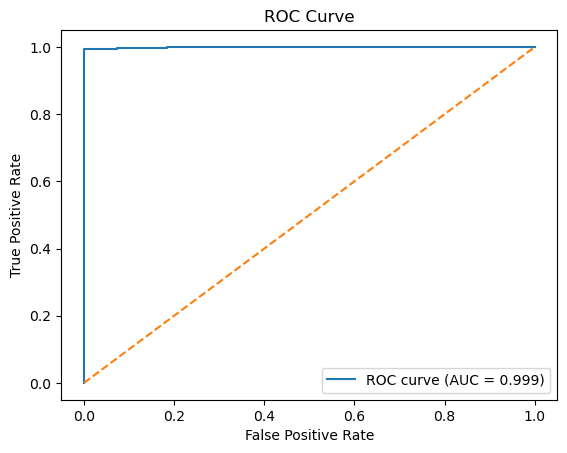

In [60]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Predict probabilities for the validation set
y_pred_prob = model.predict(X_val)   # output is probability in [0,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_val, y_pred_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

print("AUC-ROC:", roc_auc)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
